# Systematic Momentum Strategy


In [ ]:
!pip install yfinance -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

UNIVERSE = ["SPY","QQQ","IWM","EFA","EEM","VGK","EWJ","FXI",
            "XLF","XLK","XLE","XLV","XLI","XLP","XLU","XLY",
            "TLT","IEF","LQD","HYG","GLD","SLV","DBC","VNQ"]

START, END = "2015-01-01", "2025-01-01"

raw = yf.download(UNIVERSE, start=START, end=END, auto_adjust=True, progress=False)
prices = raw["Close"].dropna(how="all")
print(prices.shape)
prices.tail(3)

(2516, 24)


Ticker,DBC,EEM,EFA,EWJ,FXI,GLD,HYG,IEF,IWM,LQD,...,VGK,VNQ,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-27,20.393631,41.089504,72.338089,64.412971,29.869789,241.399994,71.991653,86.949768,219.005554,99.683182,...,60.832115,83.749458,40.356777,47.667927,130.763535,117.722939,76.230515,36.493778,135.392090,113.430336
2024-12-30,20.577446,40.759232,71.862877,63.870880,29.521227,240.630005,72.092453,87.459694,217.321548,100.113152,...,60.432148,83.334251,40.352005,47.208359,129.448654,116.225945,75.336510,36.340279,133.725891,111.608459
2024-12-31,20.683863,40.623238,71.862877,63.813820,29.472816,242.130005,72.083298,87.299149,217.597321,99.860771,...,60.441677,84.060860,40.881763,47.257256,129.291641,115.259338,75.567215,36.306709,134.047424,110.769112


In [ ]:
# --- strategy ---
def momentum_signal(prices: pd.DataFrame, lookback_months: int = 12, skip_months: int = 1) -> pd.DataFrame:
    """Classic 12-1 momentum: return over the past `lookback` months,
    excluding the most recent `skip` month (short-term reversal).

    Computed on month-end prices; returns a DataFrame of signals indexed by
    rebalance date (month end).
    """
    monthly = prices.resample("ME").last()
    mom = monthly.shift(skip_months) / monthly.shift(lookback_months) - 1.0
    return mom


def top_quantile_weights(signal: pd.DataFrame, quantile: float = 0.2) -> pd.DataFrame:
    """Equal-weight long portfolio of the top `quantile` of assets by signal.

    Assets with missing signal (insufficient history) are excluded.
    Weights sum to 1 on each rebalance date with at least one valid asset.
    """
    weights = pd.DataFrame(0.0, index=signal.index, columns=signal.columns)
    for date, row in signal.iterrows():
        valid = row.dropna()
        if valid.empty:
            continue
        n_top = max(1, int(np.ceil(len(valid) * quantile)))
        top = valid.nlargest(n_top).index
        weights.loc[date, top] = 1.0 / n_top
    return weights

In [ ]:
# --- backtest engine ---
def run_backtest(
    prices: pd.DataFrame,
    target_weights: pd.DataFrame,
    tc_bps: float = 10.0,
) -> pd.DataFrame:
    """Returns a DataFrame with daily strategy returns, costs and turnover."""
    daily_ret = prices.pct_change().fillna(0.0)
    tc = tc_bps / 1e4

    dates = daily_ret.index
    cols = prices.columns
    w_current = pd.Series(0.0, index=cols)  # holdings weights, drifting daily

    # Map each rebalance date to the first trading day strictly after it
    rebal_dates = {}
    for rd in target_weights.index:
        nxt = dates[dates > rd]
        if len(nxt):
            rebal_dates[nxt[0]] = rd

    out = pd.DataFrame(index=dates, columns=["ret", "cost", "turnover"], dtype=float)

    for d in dates:
        # 1. rebalance at the open of day d if scheduled (cost charged on day d)
        cost = 0.0
        turnover = 0.0
        if d in rebal_dates:
            w_target = target_weights.loc[rebal_dates[d]].fillna(0.0)
            turnover = float((w_target - w_current).abs().sum())
            cost = turnover * tc
            w_current = w_target.copy()

        # 2. earn the day's return on current holdings
        r = float((w_current * daily_ret.loc[d]).sum()) - cost
        out.loc[d] = [r, cost, turnover]

        # 3. drift weights with returns
        gross = w_current * (1.0 + daily_ret.loc[d])
        total = gross.sum()
        w_current = gross / total if total > 0 else gross

    return out


def equity_curve(returns: pd.Series, initial: float = 1.0) -> pd.Series:
    return initial * (1.0 + returns).cumprod()

In [ ]:
# --- metrics ---
TRADING_DAYS = 252


def cagr(returns: pd.Series) -> float:
    total = (1 + returns).prod()
    years = len(returns) / TRADING_DAYS
    return total ** (1 / years) - 1 if years > 0 else np.nan


def ann_vol(returns: pd.Series) -> float:
    return returns.std() * np.sqrt(TRADING_DAYS)


def sharpe(returns: pd.Series, rf_annual: float = 0.0) -> float:
    rf_daily = (1 + rf_annual) ** (1 / TRADING_DAYS) - 1
    excess = returns - rf_daily
    return excess.mean() / excess.std() * np.sqrt(TRADING_DAYS) if excess.std() > 0 else np.nan


def sortino(returns: pd.Series, rf_annual: float = 0.0) -> float:
    rf_daily = (1 + rf_annual) ** (1 / TRADING_DAYS) - 1
    excess = returns - rf_daily
    downside = excess[excess < 0].std()
    return excess.mean() / downside * np.sqrt(TRADING_DAYS) if downside and downside > 0 else np.nan


def max_drawdown(returns: pd.Series) -> float:
    curve = (1 + returns).cumprod()
    peak = curve.cummax()
    return float((curve / peak - 1).min())


def summary_table(strategies: dict[str, pd.Series], rf_annual: float = 0.0) -> pd.DataFrame:
    rows = {}
    for name, rets in strategies.items():
        rows[name] = {
            "CAGR": cagr(rets),
            "Ann. Vol": ann_vol(rets),
            "Sharpe": sharpe(rets, rf_annual),
            "Sortino": sortino(rets, rf_annual),
            "Max Drawdown": max_drawdown(rets),
        }
    return pd.DataFrame(rows).T.round(3)

In [ ]:
# --- run: momentum 12-1 net & gross vs equal-weight benchmark ---
LOOKBACK, TC_BPS, QUANTILE = 12, 10.0, 0.2

signal  = momentum_signal(prices, lookback_months=LOOKBACK, skip_months=1)
weights = top_quantile_weights(signal, quantile=QUANTILE)
bt       = run_backtest(prices, weights, tc_bps=TC_BPS)
bt_gross = run_backtest(prices, weights, tc_bps=0.0)

monthly_dates = prices.resample("ME").last().index
ew    = pd.DataFrame(1.0/prices.shape[1], index=monthly_dates, columns=prices.columns)
bench = run_backtest(prices, ew, tc_bps=TC_BPS)

table = summary_table({
    f"Momentum {LOOKBACK}-1 (net, {TC_BPS:.0f}bps)": bt["ret"],
    f"Momentum {LOOKBACK}-1 (gross)": bt_gross["ret"],
    "Equal-weight benchmark (net)": bench["ret"],
})
print(table)
print(f"\nAverage one-way turnover per rebalance: {bt.loc[bt['turnover']>0,'turnover'].mean():.1%}")

                               CAGR  Ann. Vol  Sharpe  Sortino  Max Drawdown
Momentum 12-1 (net, 10bps)    0.090     0.147   0.660    0.812        -0.233
Momentum 12-1 (gross)         0.096     0.147   0.698    0.859        -0.232
Equal-weight benchmark (net)  0.078     0.129   0.649    0.787        -0.277

Average one-way turnover per rebalance: 52.9%


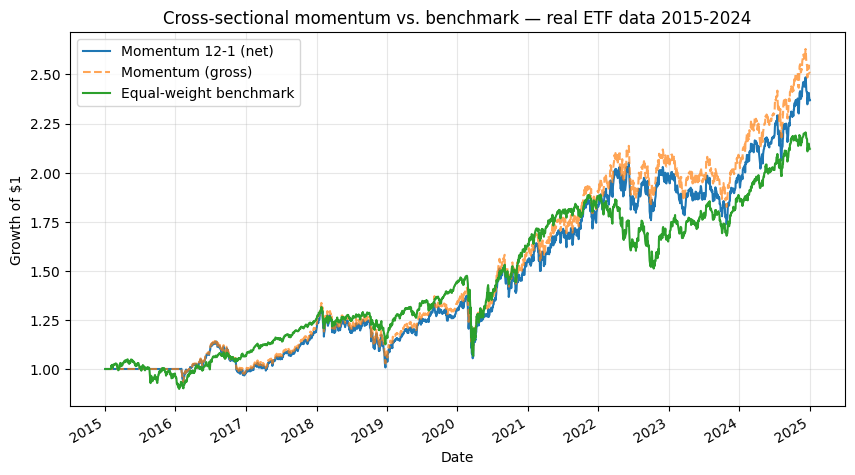

In [ ]:
# --- equity curves ---
fig, ax = plt.subplots(figsize=(10, 5.5))
equity_curve(bt["ret"]).plot(ax=ax, label=f"Momentum {LOOKBACK}-1 (net)")
equity_curve(bt_gross["ret"]).plot(ax=ax, label="Momentum (gross)", linestyle="--", alpha=0.7)
equity_curve(bench["ret"]).plot(ax=ax, label="Equal-weight benchmark")
ax.set_title("Cross-sectional momentum vs. benchmark — real ETF data 2015-2024")
ax.set_ylabel("Growth of $1"); ax.legend(); ax.grid(alpha=0.3)
plt.savefig("equity_curve_real_L12.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# --- sensitivity: lookback 6 / 9 / 12 ---
rows = {}
for lb in (6, 9, 12):
    s = momentum_signal(prices, lookback_months=lb, skip_months=1)
    w = top_quantile_weights(s, quantile=QUANTILE)
    r = run_backtest(prices, w, tc_bps=TC_BPS)
    rows[f"Momentum {lb}-1 (net)"] = r["ret"]
sens = summary_table(rows)
print(sens)
sens.to_csv("sensitivity_real.csv")

                      CAGR  Ann. Vol  Sharpe  Sortino  Max Drawdown
Momentum 6-1 (net)   0.059     0.168   0.426    0.513        -0.332
Momentum 9-1 (net)   0.079     0.151   0.581    0.704        -0.264
Momentum 12-1 (net)  0.090     0.147   0.660    0.812        -0.233
